# Autoencoders

# Problem 1
Use Pizza.csv to construct an autoencoder with 3 layers.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [8]:
# Import the csv
df = pd.read_csv('/content/Pizza.csv')
# df.head()

# Cut out columns [3,9] as the feature columns (Don't need labels because we just want to see how faithfully we can reproduce the original data)
orig_X = df.iloc[:, 2:9]
print(orig_X.head())

# Convert pandas dataframe into tensor
X = torch.tensor(orig_X.values, dtype=torch.float)

    mois   prot    fat   ash  sodium  carb   cal
0  27.82  21.43  44.87  5.11    1.77  0.77  4.93
1  28.49  21.26  43.89  5.34    1.79  1.02  4.84
2  28.35  19.99  45.78  5.08    1.63  0.80  4.95
3  30.55  20.15  43.13  4.79    1.61  1.38  4.74
4  30.49  21.28  41.65  4.82    1.64  1.76  4.67


## Part (a)
Design an optimal autoencoder with the linear encoder and decoder without nonlinear activation functions that minimize MSE. Create and test internal dimensions `h ∈ {1,2,3,4,5,6}`.

In [9]:
class Autoencoder():
  def __init__(self, hidden_dimen):
    self.input_dim = 7
    self.hidden_dim = hidden_dimen
    self.gamma = 0.0001 # Learning rate is really small because the gradient kept exploding
    self.theta1 = torch.randn(7, hidden_dimen, requires_grad=True)
    self.bias1 = torch.randn(hidden_dimen, requires_grad=True)
    self.theta2 = torch.randn(hidden_dimen, 7, requires_grad=True)
    self.bias2 = torch.randn(7, requires_grad=True)

  def encode(self, X):
    return X @ self.theta1 + self.bias1

  def encode_relu(self, X):
    return torch.relu(X @ self.theta1 + self.bias1)

  def decode(self, Z):
    return Z @ self.theta2 + self.bias2

  def loss(self, X, X_hat):
    return torch.mean((X - X_hat)**2)

  def optimizationStep(self):
    # print(self.theta1.grad)
    with torch.no_grad():
      self.theta1 -= self.gamma * self.theta1.grad
      self.bias1 -= self.gamma * self.bias1.grad
      self.theta2 -= self.gamma * self.theta2.grad
      self.bias2 -= self.gamma * self.bias2.grad

      # Zero the gradients for the next step
      self.theta1.grad.zero_()
      self.bias1.grad.zero_()
      self.theta2.grad.zero_()
      self.bias2.grad.zero_()

[76.05374145507812, 18.169736862182617, 15.183188438415527, 11.326752662658691, 2.4961531162261963, 2.1932408809661865]


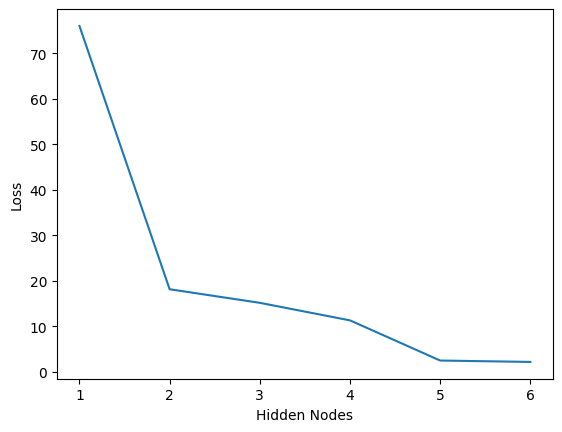

In [10]:
# Train autoencoders with different number of hidden nodes
results = []

# Train an autoencoder for hidden nodes 1 to 6 (total of 7 features so there is no encoding and decoding at 7 hidden nodes)
for h in [1,2,3,4,5,6]:
  linear_autoencoder = Autoencoder(h)

  for i in range(1000):
    Z = linear_autoencoder.encode(X)
    X_hat = linear_autoencoder.decode(Z)

    loss_value = linear_autoencoder.loss(X, X_hat)

    loss_value.backward()

    linear_autoencoder.optimizationStep()

    # At the last iteration save the loss in results
    if i == 999:
      results.append(loss_value.item())

print(results)
# Plot the loss on the y-axis against the number of hidden nodes on the x-axis using results
plt.plot([1,2,3,4,5,6], results)
plt.xlabel('Hidden Nodes')
plt.ylabel('Loss')
plt.show()

## Part (b)
Repeat the same thing in Part (a), but this time use ReLu activation functions. Plot the MSE as a function of `h`.

[441.59381103515625, 75.8655014038086, 205.20091247558594, 113.27739715576172, 63.54383850097656, 12.755796432495117]


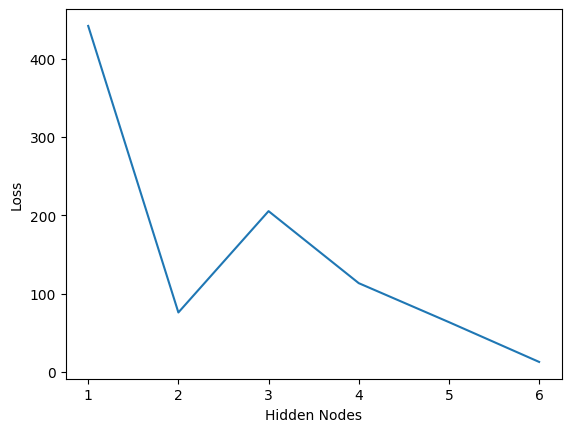

In [11]:
# Repeat the same steps using ReLu
results_relu = []

# Train an autoencoder for hidden nodes 1 to 6 (total of 7 features so there is no encoding and decoding at 7 hidden nodes)
for h in [1,2,3,4,5,6]:
  relu_autoencoder = Autoencoder(h)

  for i in range(1000):
    Z = relu_autoencoder.encode_relu(X)
    X_hat = relu_autoencoder.decode(Z)

    loss_value = relu_autoencoder.loss(X, X_hat)

    loss_value.backward()

    relu_autoencoder.optimizationStep()

    # At the last iteration save the loss in results
    if i == 999:
      results_relu.append(loss_value.item())

print(results_relu)
# Plot the results against hidden nodes
plt.plot([1,2,3,4,5,6], results_relu)
plt.xlabel('Hidden Nodes')
plt.ylabel('Loss')
plt.show()

# Problem 2

## Question
Consider the optimal autoencoder with linear encoder and decoder in problem 1(a) above. For a fixed code dimension *h*, explain how the MSE in (1) of the optimal autoencoder can be computed from the singular values of X.

## Response
1. You take the vectors corresponding to the largest *h* singular values of X and remove them (We want the MSE - the variance that is not explained by the top principal components squared and averaged).
2. Then using the leftover principal components, transform matrix X
3. Square each element
4. Sum and divide by the number of elements for the mean resulting in the MSE.

The singular values of X are analogous to the eigenvalues and eigenvectors for a square matrix, but for any matrix size and shape. Hence, the larger the singular values and their corresponding vector the more variance it explains (principal component). So for 7 features, 7 principal components should explain 100% of the variance. If the top 3 principal components explain 80% of the variance, then the bottom 4 principal components should explain the other 20%.